# ReAct Agent with LangGraph on SAP BTP

This notebook builds a **ReAct agent** using LangGraph's `StateGraph`, `ToolNode`, and `tools_condition` with the SAP GenAI Hub LangChain proxy as the LLM backend.

The graph topology is:

```
START -> assistant -> [tools_condition] -> tools -> assistant -> ... -> END
```

The assistant node calls the LLM (with bound tools). If the LLM returns tool calls, execution flows to the `tools` node; if not, it flows to `END`. This is the **same ReAct loop** as the native implementation in `../native-react/`, but expressed declaratively as a graph.

**Note:** We build the graph manually using `StateGraph` instead of using the deprecated `create_react_agent` helper, which is not available in SAP's library version.

## Import Libraries and Load Environment

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## Initialize the LLM

We use the SAP GenAI Hub LangChain proxy wrapper `ChatOpenAI`. This provides a standard LangChain `ChatModel` interface backed by SAP AI Core, so all LangChain/LangGraph components work seamlessly.

In [2]:
from gen_ai_hub.proxy.langchain.openai import ChatOpenAI

llm = ChatOpenAI(
    proxy_model_name="gpt-4.1",
    temperature=0.0,
    max_tokens=1024,
)

## Define the Tools

We import the same tool functions from `tools.py` and wrap them with the LangChain `@tool` decorator. This decorator automatically generates a JSON schema from the function signature and docstring, which the LLM uses to decide which tool to call and how to format the arguments.

After defining the tools, we bind them to the LLM with `bind_tools()`. This tells the LLM about the available tools on every call.

In [ ]:
from langchain_core.tools import tool
from tools import add as _add, multiply as _multiply, get_weather as _get_weather

# We will add the decorator @tool to the functions from tools.py to transform them into langgraph compatible tools
@tool
def add(a: float, b: float) -> float:
    """Add two numbers together. Use this for addition operations."""
    return _add(a, b)


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers together. Use this for multiplication operations."""
    return _multiply(a, b)


@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city (mock implementation for demonstration)."""
    return _get_weather(city)


tools = [add, multiply, get_weather]
llm_with_tools = llm.bind_tools(tools)

print(f"Bound {len(tools)} tools to LLM: {[t.name for t in tools]}")

Bound 3 tools to LLM: ['add', 'multiply', 'get_weather']


## Build the ReAct Graph

The graph has two nodes:

1. **`assistant`** -- calls the LLM (with bound tools) and returns the response message
2. **`tools`** -- a `ToolNode` that executes whatever tool calls the LLM requested

The routing logic is handled by `tools_condition`: if the LLM's response contains tool calls, execution goes to the `tools` node; otherwise, it goes to `END`.

```
START -> assistant -> [tools_condition] -> tools -> assistant
                                       -> END
```

In [4]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition

system_message = SystemMessage(
    content="You are a helpful assistant. Use the provided tools to answer questions. "
    "Always use a tool when a calculation or data lookup is needed."
)


def assistant(state: MessagesState):
    """Call the LLM with the current message history."""
    response = llm_with_tools.invoke([system_message] + state["messages"])
    return {"messages": [response]}


# Build the graph
graph = StateGraph(MessagesState)

graph.add_node("assistant", assistant)
graph.add_node("tools", ToolNode(tools=tools))

graph.add_edge(START, "assistant")
graph.add_conditional_edges("assistant", tools_condition)
graph.add_edge("tools", "assistant")

react_agent = graph.compile()

print("ReAct graph compiled successfully.")

ReAct graph compiled successfully.


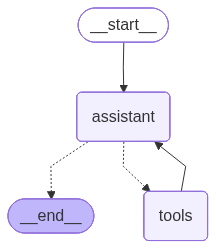

In [5]:
# Visualize the graph structure
from IPython.display import Image, display

display(Image(react_agent.get_graph().draw_mermaid_png()))

## Run the Agent

Let's test the agent with the same queries used in the native ReAct notebook for direct comparison.

In [ ]:
def print_message_trace(result: dict) -> None:
    """Print the full message trace from a graph invocation for educational purposes."""
    for msg in result["messages"]:
        role = msg.__class__.__name__
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            # Print tool calls
            tool_calls_str = ", ".join(
                f"{tc['name']}({tc['args']})" for tc in msg.tool_calls
            )
            print(f"[{role}] Tool calls: {tool_calls_str}")
        elif hasattr(msg, "content") and msg.content:
            # Print AI Message / Human Message
            print(f"[{role}] {msg.content}")
    print()

In [7]:
# Example 1: Single tool call (multiplication)
result = react_agent.invoke({"messages": [HumanMessage(content="What is 15 multiplied by 7?")]})
print_message_trace(result)

[HumanMessage] What is 15 multiplied by 7?
[AIMessage] Tool calls: multiply({'a': 15, 'b': 7})
[ToolMessage] 105.0
[AIMessage] 15 multiplied by 7 is 105.



In [8]:
# Example 2: Multi-step reasoning (addition then multiplication)
result = react_agent.invoke({"messages": [HumanMessage(content="What is 12 + 8, and then multiply the result by 3?")]})
print_message_trace(result)

[HumanMessage] What is 12 + 8, and then multiply the result by 3?
[AIMessage] Tool calls: add({'a': 12, 'b': 8})
[ToolMessage] 20.0
[AIMessage] Tool calls: multiply({'a': 20, 'b': 3})
[ToolMessage] 60.0
[AIMessage] 12 + 8 equals 20, and multiplying that result by 3 gives 60.



In [9]:
# Example 3: String argument tool (weather)
result = react_agent.invoke({"messages": [HumanMessage(content="What is the weather like in Tokyo?")]})
print_message_trace(result)

[HumanMessage] What is the weather like in Tokyo?
[AIMessage] Tool calls: get_weather({'city': 'Tokyo'})
[ToolMessage] Rainy, 18 degrees Celsius
[AIMessage] The weather in Tokyo is currently rainy with a temperature of 18 degrees Celsius.



In [10]:
# Example 4: Combined tools (weather + math)
result = react_agent.invoke({"messages": [HumanMessage(content="I need to know the weather in Berlin, and also calculate 25 + 17.")]})
print_message_trace(result)

[HumanMessage] I need to know the weather in Berlin, and also calculate 25 + 17.
[AIMessage] Tool calls: get_weather({'city': 'Berlin'}), add({'a': 25, 'b': 17})
[ToolMessage] Cloudy, 8 degrees Celsius
[ToolMessage] 42.0
[AIMessage] The current weather in Berlin is cloudy with a temperature of 8 degrees Celsius. Also, 25 + 17 equals 42.



## Summary

This notebook built the same ReAct agent loop as the native implementation, but using LangGraph's declarative graph API.

**Key differences from the native approach:**

| Aspect | Native ReAct | LangGraph ReAct |
|--------|-------------|----------------|
| Tool calling | Text parsing with regex | Structured JSON via `bind_tools` |
| Loop control | Manual `while` loop with scratchpad | Graph edges with `tools_condition` |
| State management | String concatenation | `MessagesState` with full message objects |
| Error handling | Manual try/except | Built into `ToolNode` |
| Extensibility | Requires code changes | Add nodes and edges to the graph |

For a more advanced pattern with conditional routing and specialized sub-agents, see the companion notebook `02_multi_step_workflow.ipynb`.